Criar um mapa de ondas de calor por região: subdividindo em 8 regiões.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from datetime import timedelta

# Lista das estações fornecidas
estacoes = ['vidigal', 'saocristovao', 'santacruz', 'riocentro', 'jb', 'iraja', 'guaratiba', 'alto']

# Criar pastas para organizar a saída
os.makedirs('data_csv', exist_ok=True)
os.makedirs('heatwaves_reports', exist_ok=True)

Código para transformar o txt em dataframe.

In [ ]:
import pandas as pd
import glob
import os

def ler_estacao_sem_erros(caminho_arquivo):
    """
    Realiza o parsing manual das linhas para tratar a variabilidade de tokens (8 vs 9).
    """
    colunas_finais = ['Dia', 'Hora', 'HBV', 'Chuva', 'DirVento', 'VelVento', 'Temperatura', 'Pressao', 'Umidade']
    registros = []

    try:
        with open(caminho_arquivo, 'r', encoding='latin-1') as f:
            # Ignora as 7 linhas iniciais de metadados
            linhas = f.readlines()[7:]
            
            for linha in linhas:
                tokens = linha.split()
                if not tokens or '/' not in tokens[0]:
                    continue
                
                # Normalização lógica do esquema
                n_tokens = len(tokens)
                if n_tokens == 8:
                    # Caso HBV vazio: injeta None na posição 2
                    linha_normalizada = tokens[:2] + [None] + tokens[2:]
                elif n_tokens == 9:
                    # Caso HBV presente
                    linha_normalizada = tokens
                else:
                    # Ignora linhas malformadas
                    continue
                
                registros.append(linha_normalizada)
        
        df = pd.DataFrame(registros, columns=colunas_finais)
        
        # Conversão rigorosa de tipos
        df['Temperatura'] = pd.to_numeric(df['Temperatura'].replace('ND', None), errors='coerce')
        df['datetime'] = pd.to_datetime(df['Dia'] + ' ' + df['Hora'], dayfirst=True, errors='coerce')
        
        return df.dropna(subset=['datetime'])

    except Exception as e:
        print(f"Falha ao processar {caminho_arquivo}: {e}")
        return None

# Processamento consolidado por estação
def consolidar_pastas_estacoes(lista_estacoes, diretorio_raiz):
    for est in lista_estacoes:
        pasta = os.path.join(diretorio_raiz, f'dados_climaticos_{est}')
        arquivos = glob.glob(os.path.join(pasta, "*.txt"))
        
        dfs_estacao = []
        for arq in arquivos:
            df_mes = ler_estacao_sem_erros(arq)
            if df_mes is not None:
                dfs_estacao.append(df_mes)
        if dfs_estacao:
            full_df = pd.concat(dfs_estacao).sort_values('datetime')
            full_df.to_csv(f"{est}_consolidado.csv", index=False)
            print(f"Estação {est}: Processada com sucesso.")
        return



Estação vidigal: Processada com sucesso.
Estação saocristovao: Processada com sucesso.
Estação santacruz: Processada com sucesso.
Estação riocentro: Processada com sucesso.
Estação jb: Processada com sucesso.
Estação iraja: Processada com sucesso.
Estação guaratiba: Processada com sucesso.
Estação alto: Processada com sucesso.


In [ ]:

consolidar_pastas_estacoes('dados_climaticos_alto', 'alto_da_boa_vista')
consolidar_pastas_estacoes('dados_climaticos_guaratiba', 'guaratiba')
consolidar_pastas_estacoes('dados_climaticos_iraja', 'iraja')
consolidar_pastas_estacoes('dados_climaticos_jb', 'jb')
consolidar_pastas_estacoes('dados_climaticos_riocentro', 'riocentro')
consolidar_pastas_estacoes('dados_climaticos_santacruz', 'santacruz')
consolidar_pastas_estacoes('dados_climaticos_saocristovao', 'saocristovao')
consolidar_pastas_estacoes('dados_climaticos_vidigal', 'vidigal')
df_alto = pd.read_csv('alto_da_boa_vista_consolidado.csv')
df_guaratiba = pd.read_csv('guaratiba_consolidado.csv')
df_iraja = pd.read_csv('iraja_consolidado.csv')
df_jb = pd.read_csv('jb_consolidado.csv')
df_riocentro = pd.read_csv('riocentro_consolidado.csv')
df_santacruz = pd.read_csv('santacruz_consolidado.csv')
df_saocristovao = pd.read_csv('saocristovao_consolidado.csv')


In [ ]:
print(df_alto.head())
print(df_guaratiba.head())
print(df_iraja.head())
print(df_jb.head())
print(df_riocentro.head())
print(df_santacruz.head())
print(df_saocristovao.head())


          Dia      Hora  Chuva  DirVento  VelVento  Temperatura  Pressao  \
0  01/01/2025  00:05:00    0.0       NaN       NaN         20.3      NaN   
1  01/01/2025  00:10:00    0.0       NaN       NaN         20.5      NaN   
2  01/01/2025  00:15:00    0.0       NaN       NaN         20.5      NaN   
3  01/01/2025  00:20:00    0.0       NaN       NaN         20.8      NaN   
4  01/01/2025  00:25:00    0.0       NaN       NaN         20.8      NaN   

   Umidade             datetime  
0      100  2025-01-01 00:05:00  
1      100  2025-01-01 00:10:00  
2      100  2025-01-01 00:15:00  
3      100  2025-01-01 00:20:00  
4      100  2025-01-01 00:25:00  
          Dia      Hora  HBV Chuva DirVento VelVento  Temperatura Pressao  \
0  01/01/2025  00:05:00  NaN   0.0      224      5.6         23.6  1008.3   
1  01/01/2025  00:10:00  NaN   0.0      223      3.2         23.7  1008.3   
2  01/01/2025  00:15:00  NaN   0.0      223      2.8         23.8  1008.2   
3  01/01/2025  00:20:00  NaN   

Para detectar ondas de calor.

In [ ]:
def detectar_eventos_calor(df, n_dias=2):
    """
    Detecta ondas de calor garantindo a tipagem correta dos dados temporais.
    """
    # Conversão explícita para datetime para evitar o TypeError
    if not pd.api.types.is_datetime64_any_dtype(df['datetime']):
        df['datetime'] = pd.to_datetime(df['datetime'])
    
    # 1. Obter a temperatura máxima de cada dia
    # O resample exige que a coluna alvo seja datetime64
    daily_max = df.resample('D', on='datetime')['Temperatura'].max().to_frame()
    
    # 2. Calcular o Percentil 90 (Threshold de calor extremo para esta estação)
    threshold = daily_max['Temperatura'].quantile(0.90)
    
    # 3. Identificar dias que excedem o limite
    daily_max['extremo'] = daily_max['Temperatura'] >= threshold
    
    # 4. Lógica de consecutividade
    daily_max['bloco'] = (daily_max['extremo'] != daily_max['extremo'].shift()).cumsum()
    
    # Filtro de persistência: n_dias consecutivos
    ondas_calor = (daily_max[daily_max['extremo']]
                   .groupby('bloco')
                   .filter(lambda x: len(x) >= n_dias))
    
    return ondas_calor, threshold

Obtendo as ondas de calor.

In [ ]:
ondas_alto, limite_alto = detectar_eventos_calor(df_alto)
ondas_guaratiba, limite_guaratiba = detectar_eventos_calor(df_guaratiba)
ondas_iraja, limite_iraja = detectar_eventos_calor(df_iraja)
ondas_jb, limite_jb = detectar_eventos_calor(df_jb)
ondas_riocentro, limite_riocentro = detectar_eventos_calor(df_riocentro)
ondas_santacruz, limite_santacruz = detectar_eventos_calor(df_santacruz)
ondas_saocristovao, limite_saocristovao = detectar_eventos_calor(df_saocristovao)


Para visualizar.

In [29]:
import matplotlib.dates as mdates

def visualizar_analise_calor(df, ondas_calor, threshold, nome_estacao):
    """
    Gera um gráfico da série temporal de temperatura destacando o threshold P90
    e sombreando os períodos de ondas de calor detectados.
    """
    plt.figure(figsize=(15, 7))
    ax = plt.gca()

    # 1. Plotagem da temperatura (série principal)
    plt.plot(df['datetime'], df['Temperatura'], color='gray', alpha=0.3, label='Temperatura (Sinal Bruto)')
    
    # 2. Plotagem da máxima diária (para clareza estatística)
    daily_max = df.resample('D', on='datetime')['Temperatura'].max()
    plt.plot(daily_max.index, daily_max.values, color='black', linewidth=1, label='Máxima Diária')

    # 3. Linha do Limite Crítico (P90)
    plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, 
                label=f'Limite Crítico P90 ({threshold:.2f}°C)')

    # 4. Sombreamento das Ondas de Calor
    # Agrupamos por 'bloco' para pintar cada evento individualmente
    if not ondas_calor.empty:
        for _, group in ondas_calor.groupby('bloco'):
            inicio = group.index.min()
            fim = group.index.max()
            plt.axvspan(inicio, fim, color='orange', alpha=0.4, label='Onda de Calor' if _ == ondas_calor['bloco'].iloc[0] else "")

    # 5. Formatação do Eixo X (Datas)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
    plt.xticks(rotation=45)

    # 6. Metadados e Estética
    plt.title(f'Análise de Estresse Térmico: Estação {nome_estacao.upper()}', fontsize=14, pad=20)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.xlabel('Período', fontsize=12)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# visualizar_analise_calor(df_alto, ondas, limite, "Alto da Boa Vista")


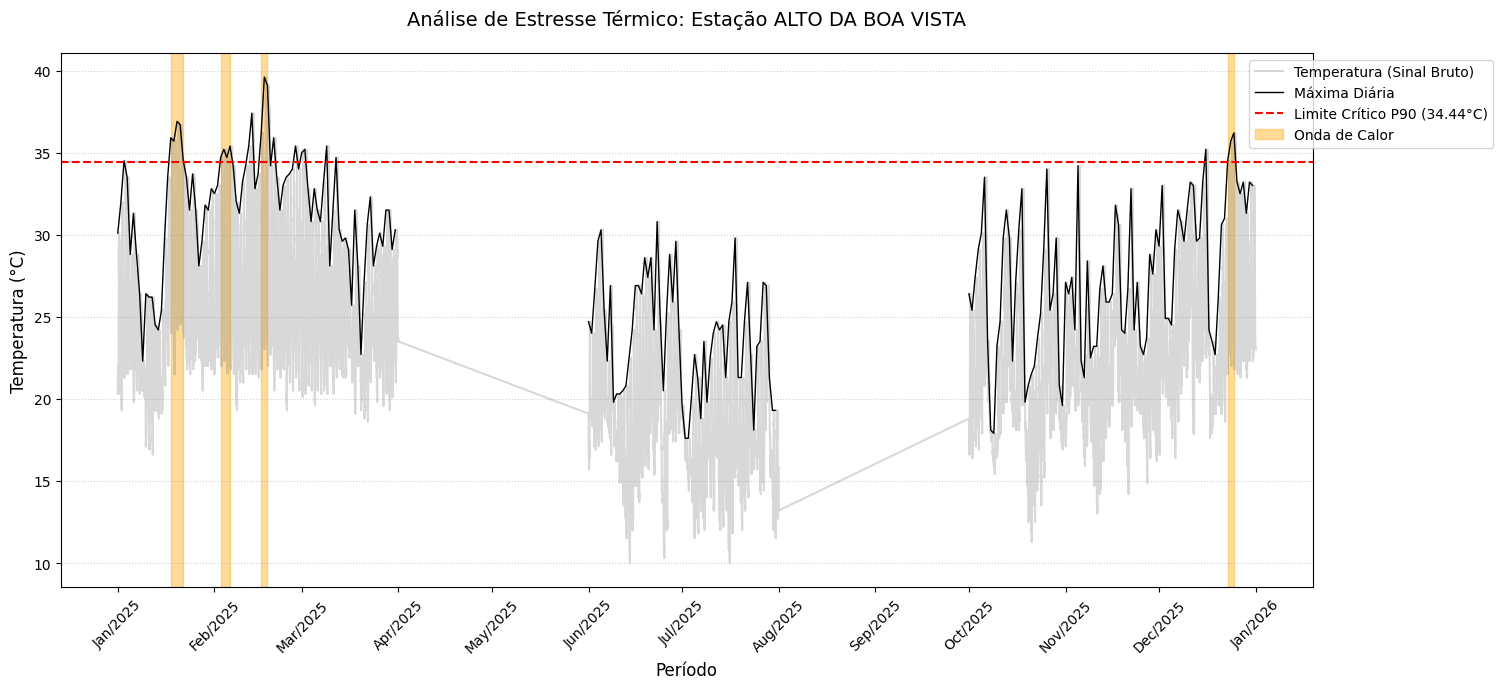

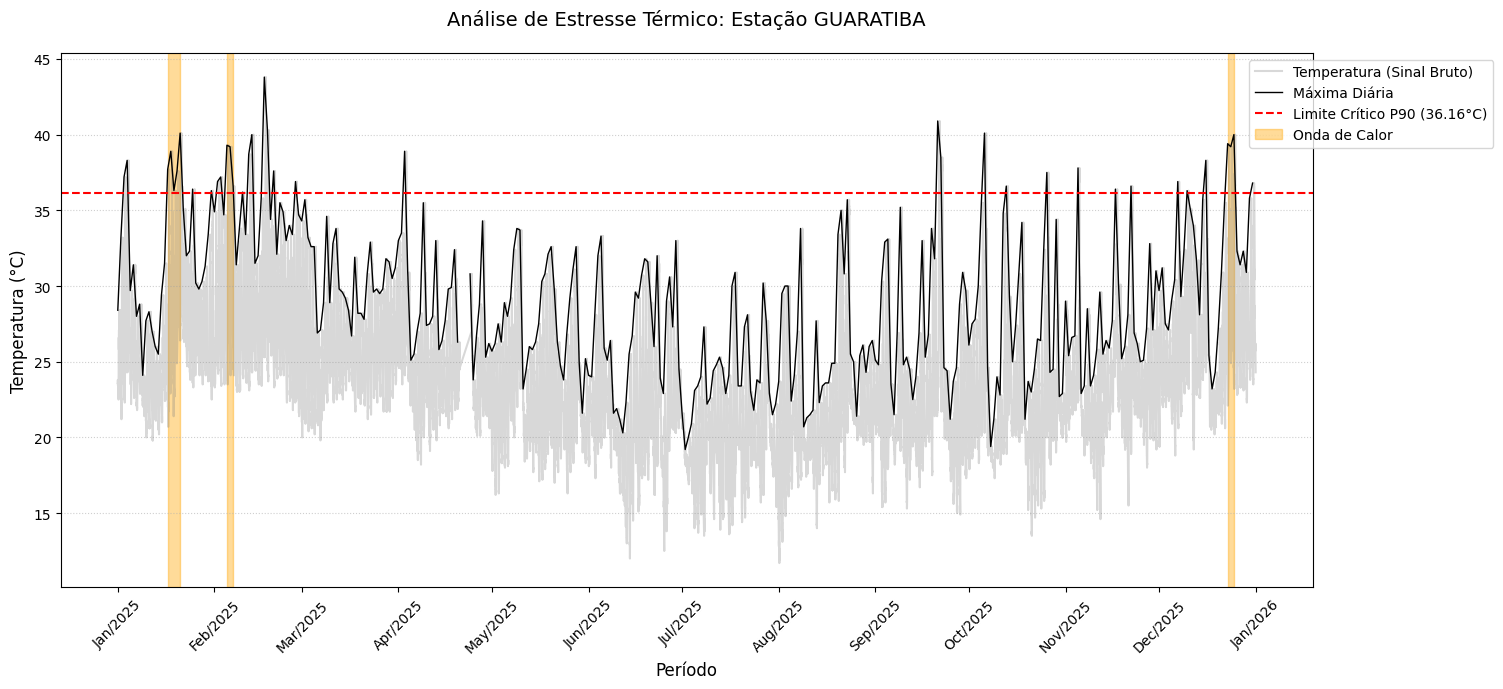

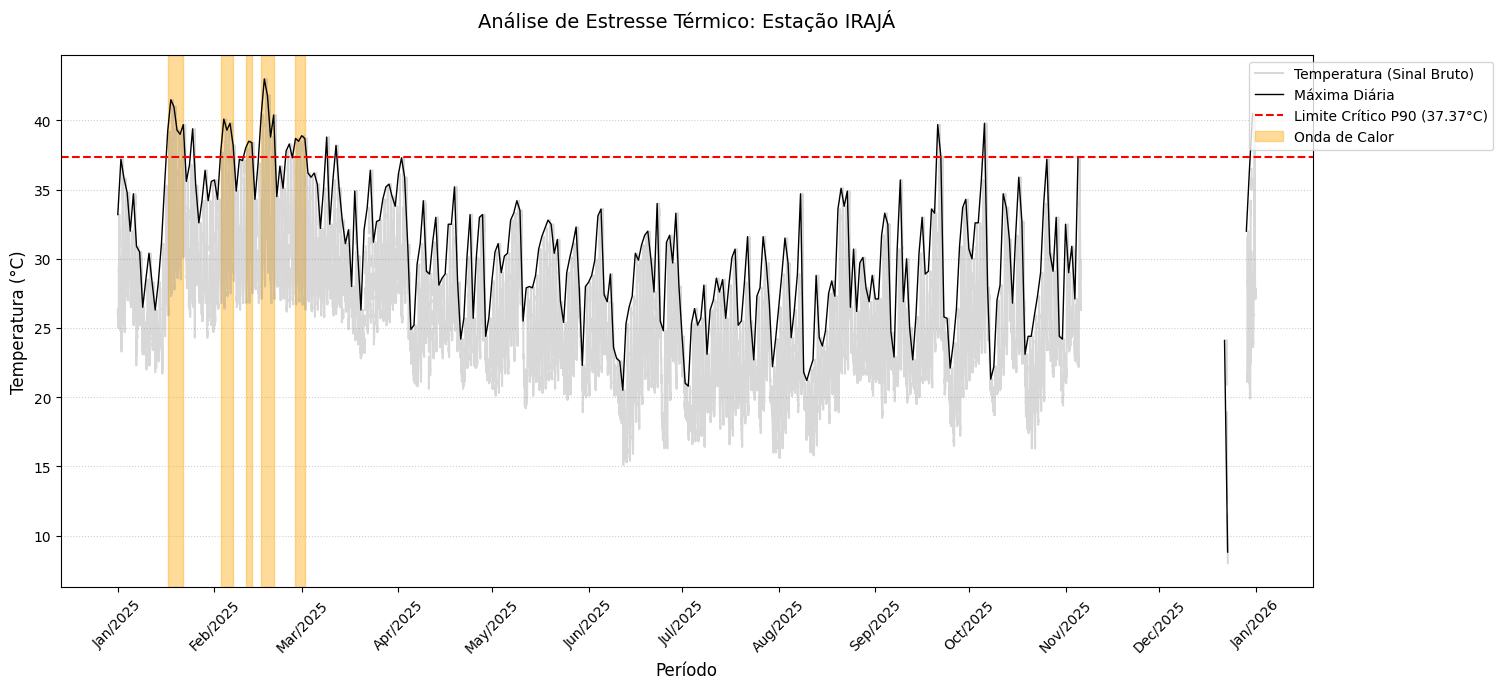

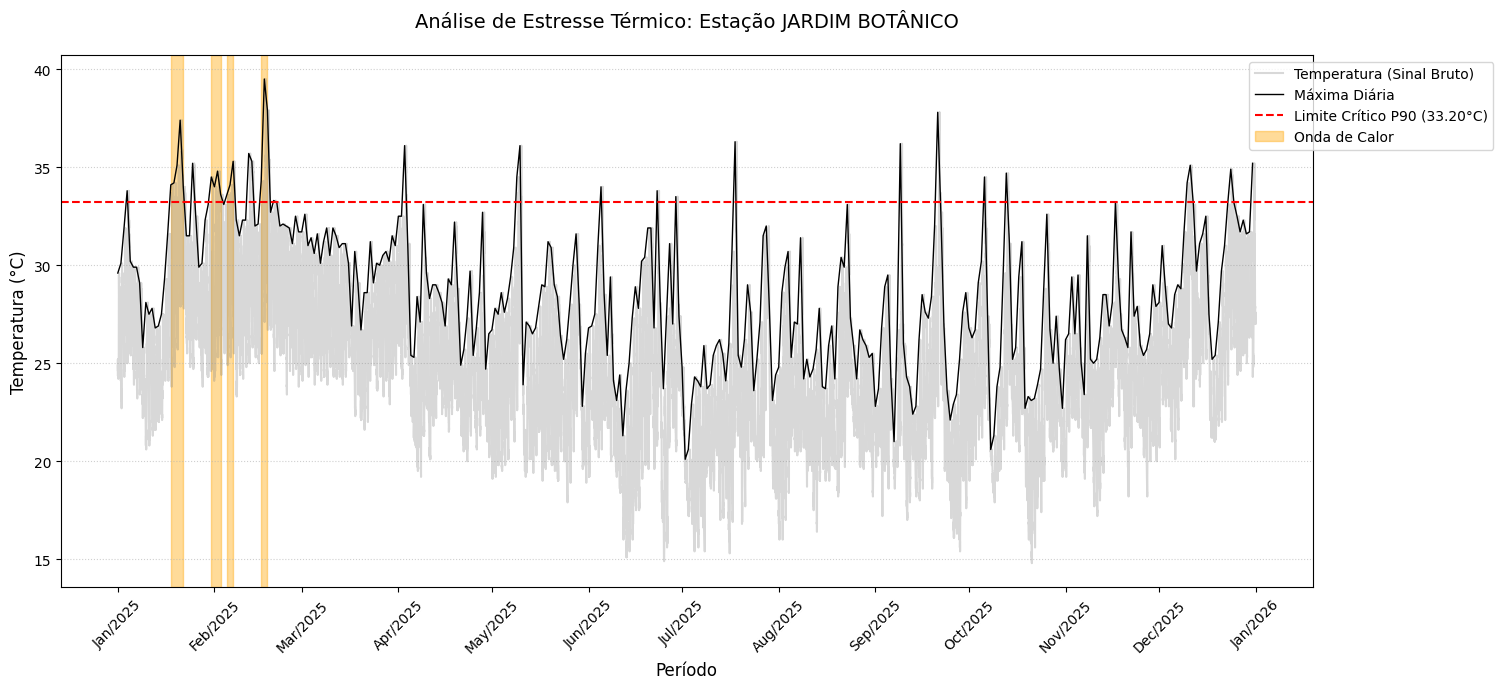

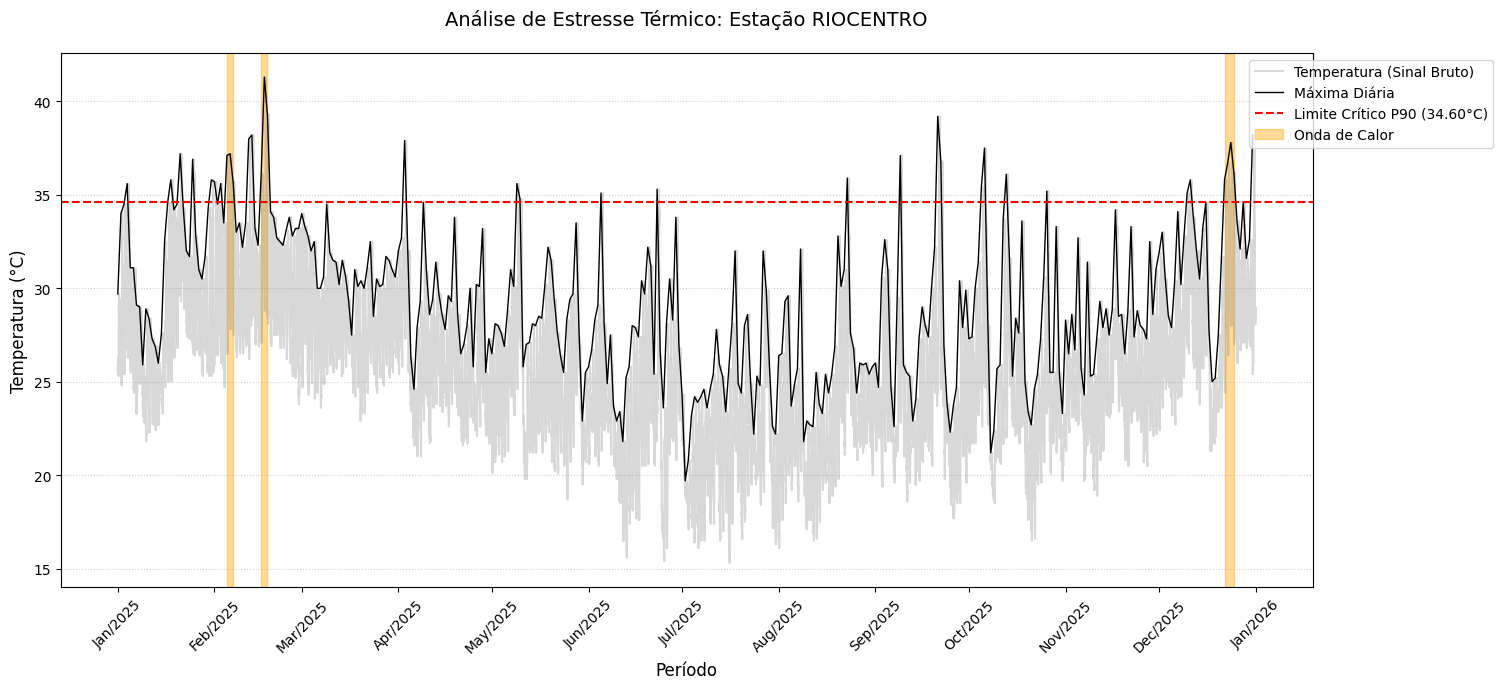

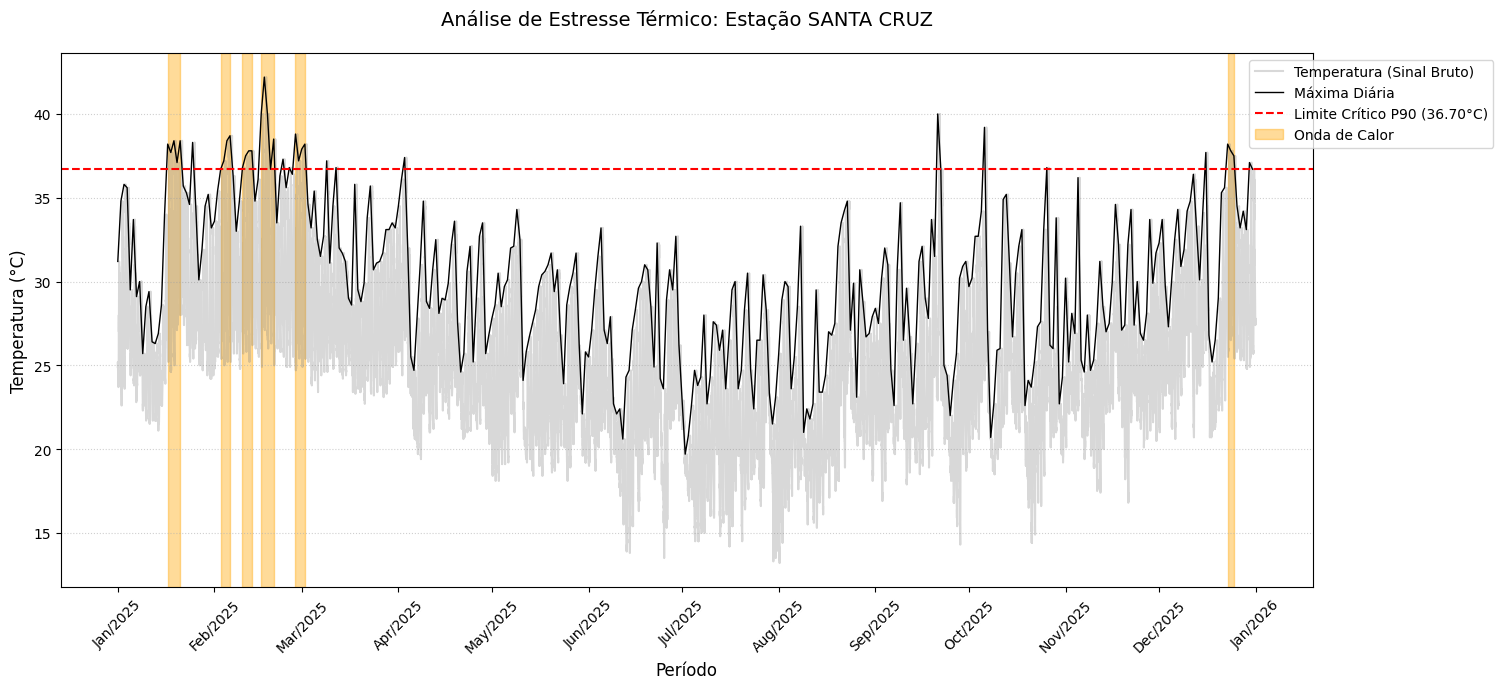

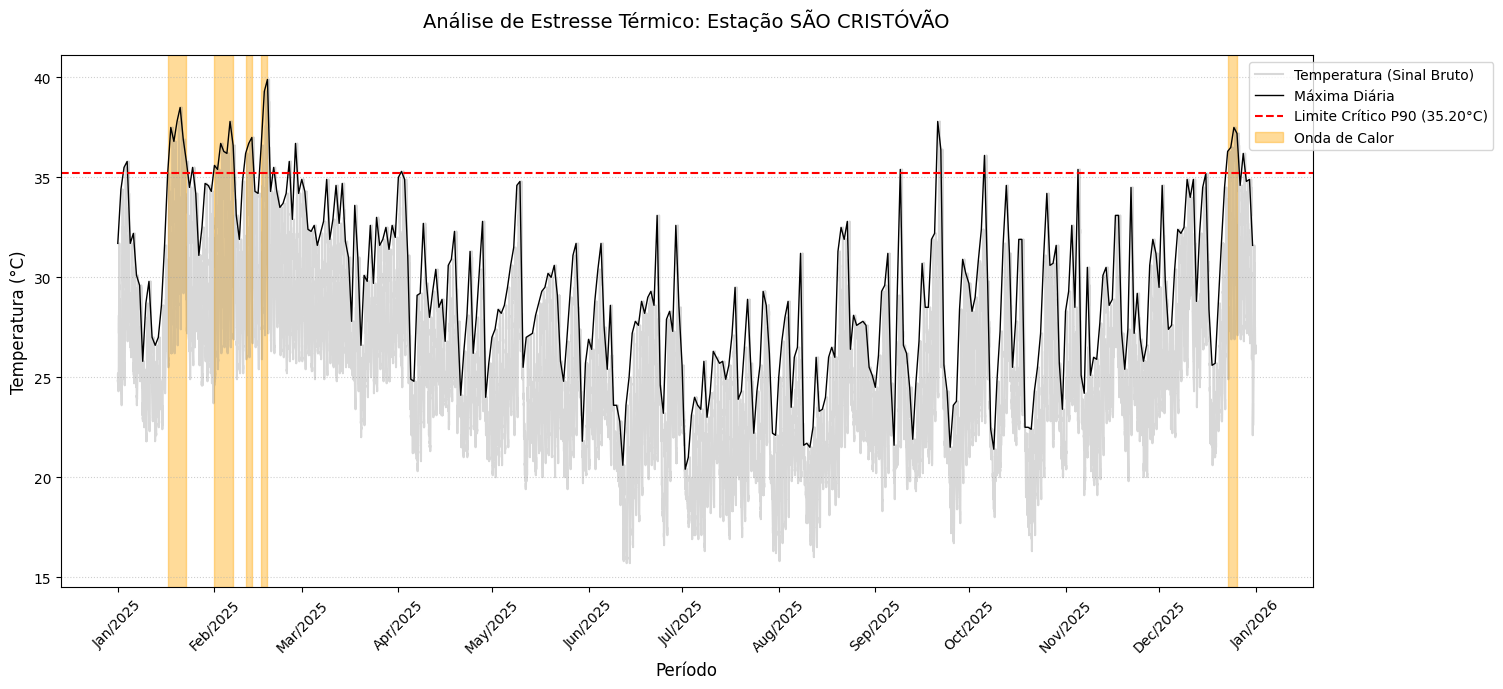

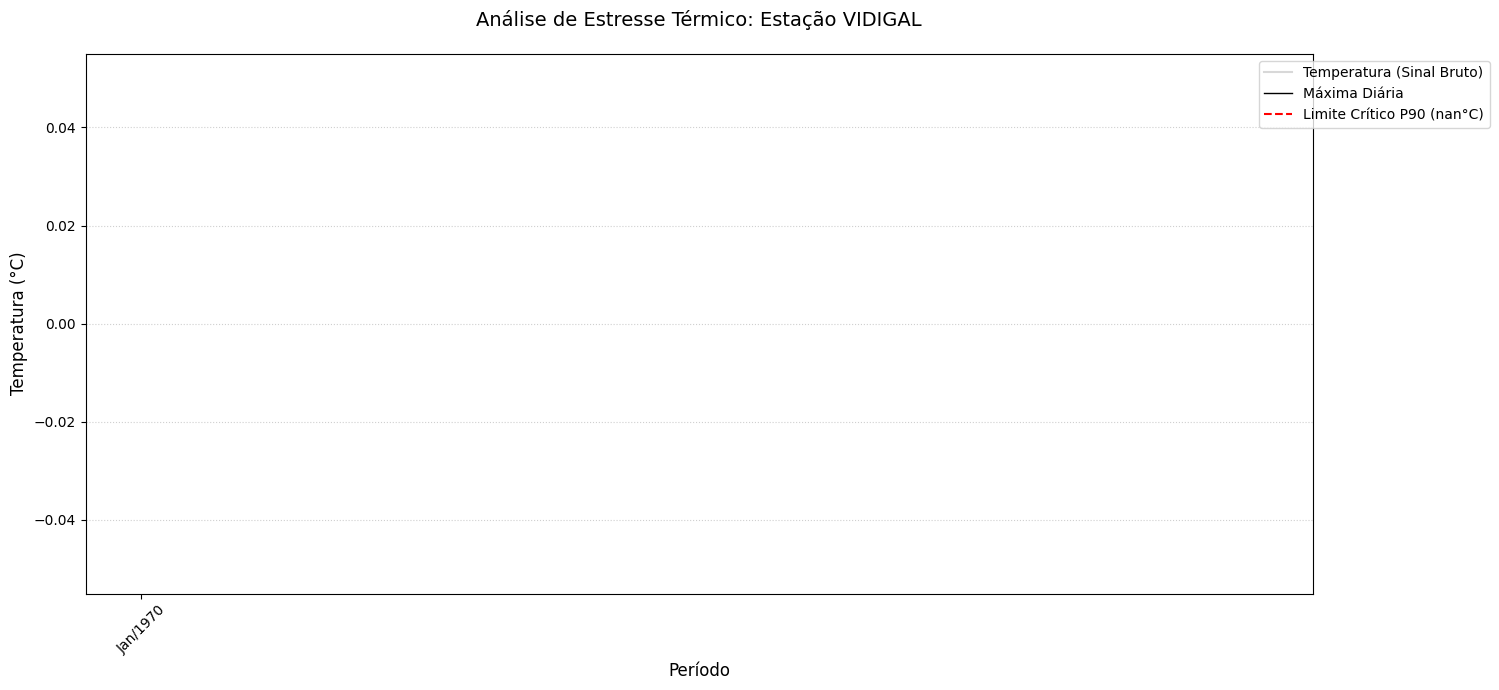

In [ ]:
visualizar_analise_calor(df_alto, ondas_alto, limite_alto, "Alto da Boa Vista")
visualizar_analise_calor(df_guaratiba, ondas_guaratiba, limite_guaratiba, "Guaratiba")
visualizar_analise_calor(df_iraja, ondas_iraja, limite_iraja, "Irajá")
visualizar_analise_calor(df_jb, ondas_jb, limite_jb, "Jardim Botânico")
visualizar_analise_calor(df_riocentro, ondas_riocentro, limite_riocentro, "Riocentro")
visualizar_analise_calor(df_santacruz, ondas_santacruz, limite_santacruz, "Santa Cruz")
visualizar_analise_calor(df_saocristovao, ondas_saocristovao, limite_saocristovao, "São Cristóvão")

